Test accuracy (linear on concatenation):   0.504
Test accuracy (linear after tanh mixing):  0.957


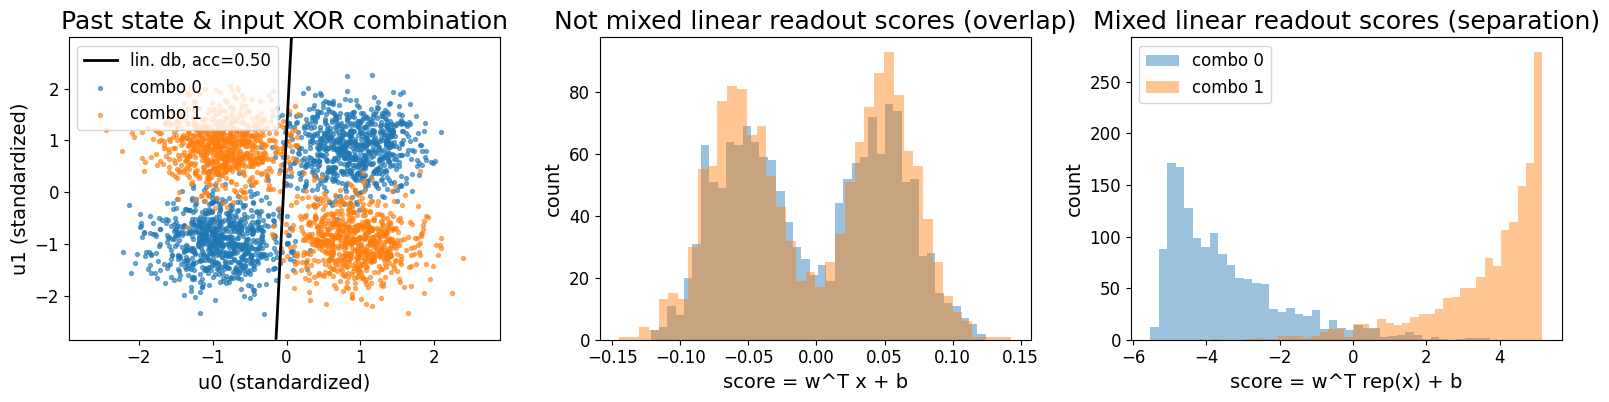

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- data ----------
def make_noisy_xor(n=6000, noise=0.25, seed=1):
    rng = np.random.default_rng(seed)
    u0 = rng.integers(0, 2, size=n)
    u1 = rng.integers(0, 2, size=n)
    y  = (u0 ^ u1).astype(int)
    X  = np.stack([u0, u1], axis=1).astype(float)
    X += rng.normal(scale=noise, size=X.shape)  # jitter around the 4 corners
    return X, y

def standardize_fit(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-8
    return mu, sd

def standardize_apply(X, mu, sd):
    return (X - mu) / sd

# ---------- logistic regression (GD) ----------
def train_logreg(X, y, lr=0.3, steps=4000, l2=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = rng.normal(scale=0.1, size=d)
    b = 0.0
    y = y.astype(float)
    for _ in range(steps):
        z = X @ w + b
        p = 1.0 / (1.0 + np.exp(-z))
        gw = (X.T @ (p - y)) / n + l2 * w
        gb = np.mean(p - y)
        w -= lr * gw
        b -= lr * gb
    return w, b

def pred_prob(X, w, b):
    return 1.0 / (1.0 + np.exp(-(X @ w + b)))

def accuracy(X, y, w, b):
    yhat = (pred_prob(X, w, b) >= 0.5).astype(int)
    return np.mean(yhat == y)

# ---------- nonlinear mixing ----------
def tanh_features(X, m=200, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(scale=1.0, size=(m, X.shape[1]))
    c = rng.normal(scale=0.2, size=(m,))
    Phi = np.tanh(X @ W.T + c)
    return Phi, W, c

# ---------- plotting helpers ----------
def plot_boundary(ax, w, b, xlim, ylim):
    xs = np.linspace(xlim[0], xlim[1], 250)
    ys = np.linspace(ylim[0], ylim[1], 250)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
    probs = pred_prob(grid, w, b).reshape(YY.shape)
    ax.contour(XX, YY, probs, levels=[0.5], colors='k', linewidths=2)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)

# ---------- run experiment ----------
X, y = make_noisy_xor(n=8000, noise=0.25, seed=1)

# train/test split
rng = np.random.default_rng(0)
idx = rng.permutation(len(y))
tr, te = idx[:5000], idx[5000:]
Xtr, ytr = X[tr], y[tr]
Xte, yte = X[te], y[te]

# standardize based on train
mu, sd = standardize_fit(Xtr)
Xtr_s = standardize_apply(Xtr, mu, sd)
Xte_s = standardize_apply(Xte, mu, sd)

# (A) Linear readout on concatenation
w_raw, b_raw = train_logreg(Xtr_s, ytr, seed=0)
acc_raw = accuracy(Xte_s, yte, w_raw, b_raw)
scores_raw = Xte_s @ w_raw + b_raw

# (B) Linear readout after nonlinear mixing
Phi_tr, W, c = tanh_features(Xtr_s, m=200, seed=0)
Phi_te = np.tanh(Xte_s @ W.T + c)
w_mix, b_mix = train_logreg(Phi_tr, ytr, seed=0)
acc_mix = accuracy(Phi_te, yte, w_mix, b_mix)
scores_mix = Phi_te @ w_mix + b_mix

print(f"Test accuracy (linear on concatenation):   {acc_raw:.3f}")
print(f"Test accuracy (linear after tanh mixing):  {acc_mix:.3f}")

# ---------- plots ----------
fig, axs = plt.subplots(1, 3, figsize=(16, 4.3))

# Left: raw concatenation scatter + boundary
ax = axs[0]
ax.scatter(Xte_s[yte==0,0], Xte_s[yte==0,1], s=8, alpha=0.6, label="combo 0")
ax.scatter(Xte_s[yte==1,0], Xte_s[yte==1,1], s=8, alpha=0.6, label="combo 1")
xlim = (Xte_s[:,0].min()-0.5, Xte_s[:,0].max()+0.5)
ylim = (Xte_s[:,1].min()-0.5, Xte_s[:,1].max()+0.5)
plot_boundary(ax, w_raw, b_raw, xlim, ylim)

ax.set_xlabel("u0 (standardized)")
ax.set_ylabel("u1 (standardized)")
ax.legend(handles=[
    Line2D([0], [0], linewidth=2, label="lin. db, acc={acc:.2f}".format(acc=acc_raw), color='k'),
    *ax.get_legend_handles_labels()[0]
])
ax.set_title("Past state & input XOR combination")

# Right: score histograms (raw vs mixed)
ax = axs[1]
ax.hist(scores_raw[yte==0], bins=40, alpha=0.45)
ax.hist(scores_raw[yte==1], bins=40, alpha=0.45)
ax.set_title("Not mixed linear readout scores (overlap)")
ax.set_xlabel("score = w^T x + b")
ax.set_ylabel("count")

# Right: score histograms (raw vs mixed)
ax = axs[2]
ax.hist(scores_mix[yte==0], bins=40, alpha=0.45, label="combo 0")
ax.hist(scores_mix[yte==1], bins=40, alpha=0.45, label="combo 1")
ax.set_title("Mixed linear readout scores (separation)")
ax.set_xlabel("score = w^T rep(x) + b")
ax.set_ylabel("count")
ax.legend()

plt.tight_layout()
plt.show()


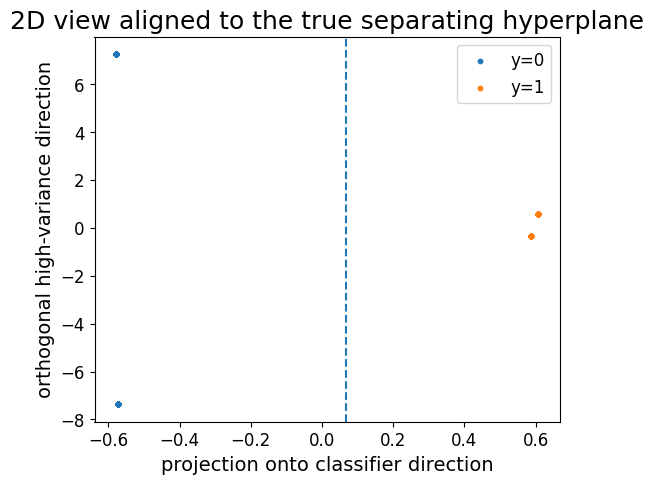

In [28]:
# Build a 2D coordinate system: [projection onto w, projection onto an orthogonal variance axis]
Z = Phi_te - Phi_te.mean(axis=0, keepdims=True)

w = w2.copy()
w_norm = np.linalg.norm(w) + 1e-12
w_unit = w / w_norm

# component along w
x1 = Z @ w_unit

# find a high-variance direction orthogonal to w by PCA on the residual
Z_res = Z - np.outer(x1, w_unit)
C = (Z_res.T @ Z_res) / Z_res.shape[0]
evals, evecs = np.linalg.eigh(C)
v2 = evecs[:, np.argsort(evals)[::-1][0]]  # top eigenvector of residual
x2 = Z @ v2

plt.figure(figsize=(6,5))
plt.scatter(x1[yte==0], x2[yte==0], s=10, label="y=0")
plt.scatter(x1[yte==1], x2[yte==1], s=10, label="y=1")
plt.axvline(-b2 / w_norm, linestyle="--")  # boundary in x1-coordinate
plt.title("2D view aligned to the true separating hyperplane")
plt.xlabel("projection onto classifier direction")
plt.ylabel("orthogonal high-variance direction")
plt.legend()
plt.show()

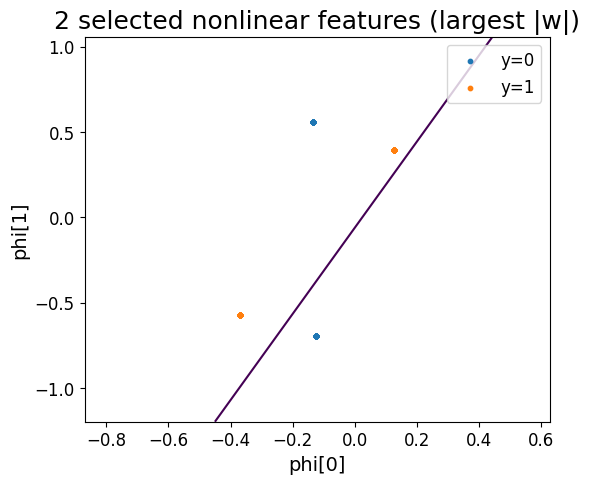

In [31]:
j1, j2 = np.argsort(np.abs(w2))[-2:]
X2 = Phi_te[:, [j1, j2]]

# fit a 2D linear classifier just for a boundary in this plane
w2, b2 = train_logistic_regression(X2, yte, seed=0)

def plot_boundary(ax, w, b, X2):
    xlim = (X2[:,0].min()-0.5, X2[:,0].max()+0.5)
    ylim = (X2[:,1].min()-0.5, X2[:,1].max()+0.5)
    xs = np.linspace(*xlim, 200)
    ys = np.linspace(*ylim, 200)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
    probs = 1/(1+np.exp(-(grid @ w + b)))
    ax.contour(XX, YY, probs.reshape(YY.shape), levels=[0.5])

plt.figure(figsize=(6,5))
plt.scatter(X2[yte==0,0], X2[yte==0,1], s=10, label="y=0")
plt.scatter(X2[yte==1,0], X2[yte==1,1], s=10, label="y=1")
plot_boundary(plt.gca(), w2, b2, X2)
plt.title("2 selected nonlinear features (largest |w|)")
plt.xlabel(f"phi[{j1}]")
plt.ylabel(f"phi[{j2}]")
plt.legend()
plt.show()


In [26]:
np.unique(scores[yte==0], return_counts=True)

(array([-4.35879941, -4.35879941, -4.30130924, -4.30130924]),
 array([ 12, 494,  27, 486]))

In [19]:
np.unique(yte)

array([0., 1.])

In [ ]:
yte

array([1, 1, 0, ..., 1, 1, 0])

In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

Begin by defining neural networks as functions.
\begin{equation}
    f(x) = \tilde{\alpha}^{(L)}(x;\theta)
\end{equation}
where \( \tilde{\alpha}^{(l)} \) are the preactivations at layer \( l \) and \( \theta \) represents the parameters of the network. The activations \( \( \alpha^{(l)} \) ) are obtained by applying a non-linear activation function \( \sigma \) to the preactivations of the previous layer thus setting up the recursive relationship:
\begin{align}
    \alpha^{(0)}(x;\theta) &= x \\
    \tilde{\alpha}^{(l)}(x;\theta) &= W^{(l)} \alpha^{(l-1)}(x;\theta) + b^{(l)} \\
    \alpha^{(l)}(x;\theta) &= \sigma\left(\tilde{\alpha}^{(l-1)}(x;\theta)\right)
\end{align}
for \( l = 1, \ldots, L \), where \( W^{(l)} \) and \( b^{(l)} \) are the weights and biases of layer \( l \).

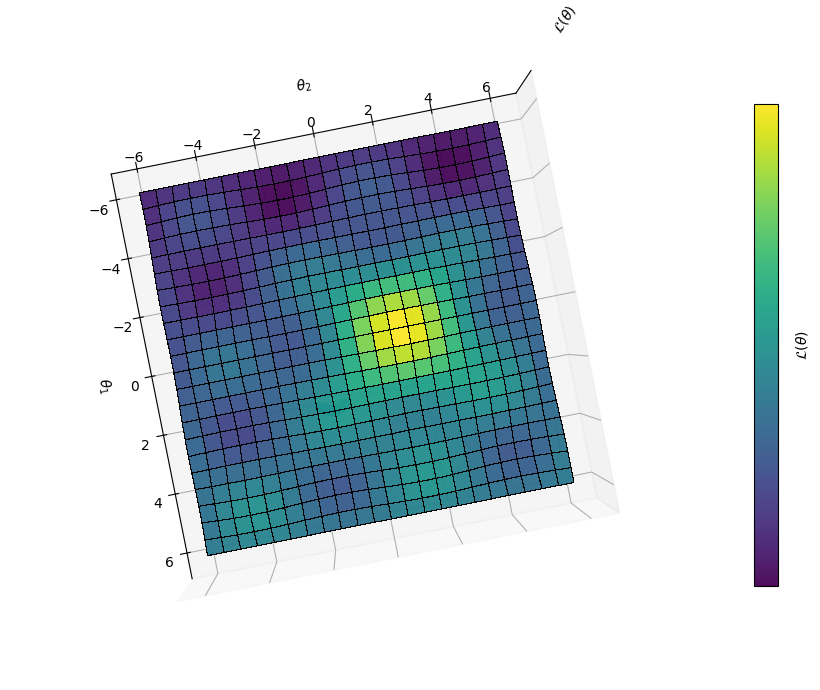

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ----------------------------
# Synthetic objective landscape
# ----------------------------
def L(theta1, theta2):
    """
    Smooth, nonconvex surface (for visualization only).
    Interpretable as an objective L(θ) to MAXIMIZE (gradient ascent).
    """
    return (
        1.2 * np.exp(-0.15 * (theta1**2 + (theta2 - 1.5)**2))   # broad hill
        + 0.25 * np.cos(1.3 * theta1) * np.sin(1.1 * theta2)    # gentle ripples
        + 0.05 * (theta1 - 2.0)                                  # slight tilt
    )

def grad_L(theta1, theta2, eps=1e-4):
    """Finite-difference gradient of L for simplicity."""
    d1 = (L(theta1 + eps, theta2) - L(theta1 - eps, theta2)) / (2 * eps)
    d2 = (L(theta1, theta2 + eps) - L(theta1, theta2 - eps)) / (2 * eps)
    return np.array([d1, d2])

# Surface grid
t1 = np.linspace(-6, 6, 220)
t2 = np.linspace(-6, 6, 220)
T1, T2 = np.meshgrid(t1, t2)
Z = L(T1, T2)

# ----------------------------
# Gradient ascent trajectory
# ----------------------------
theta = np.array([2, -1.5])  # starting point
lr = 0.6
n_steps = 18

traj = [theta.copy()]
for _ in range(n_steps):
    g = grad_L(theta[0], theta[1])
    theta = theta + lr * g              # ascent toward higher L
    # theta = theta - lr * g            # (optional) descent toward lower L
    traj.append(theta.copy())

traj = np.array(traj)
traj_z = L(traj[:, 0], traj[:, 1])

# ----------------------------
# Plot
# ----------------------------
fig = plt.figure(figsize=(9.5, 7.0))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    T1, T2, Z,
    rstride=10, cstride=10,
    cmap=cm.viridis,
    linewidth=1E-2,
    antialiased=False,
    shade=False,
    alpha=0.95, edgecolors='k'
)

# Trajectory: line + dots
ax.plot(traj[:, 0], traj[:, 1], traj_z, linewidth=2.5)
ax.scatter(traj[:, 0], traj[:, 1], traj_z, s=40, depthshade=False)

# Labels
ax.set_xlabel(r"$\theta_1$", labelpad=10)
ax.set_ylabel(r"$\theta_2$", labelpad=10)
ax.set_zlabel(r"$\mathcal{L}(\theta)$", labelpad=10)

# Remove numeric ticks (axes + colorbar)
# ax.set_xticks([])
# ax.set_yticks([])
ax.set_zticks([])

cbar = fig.colorbar(surf, ax=ax, shrink=0.72, pad=0.08)
cbar.set_label(r"$\mathcal{L}(\theta)$", rotation=90, labelpad=12)
cbar.set_ticks([])

# Camera angle
ax.view_init(elev=90, azim=-6)

plt.tight_layout()
plt.show()


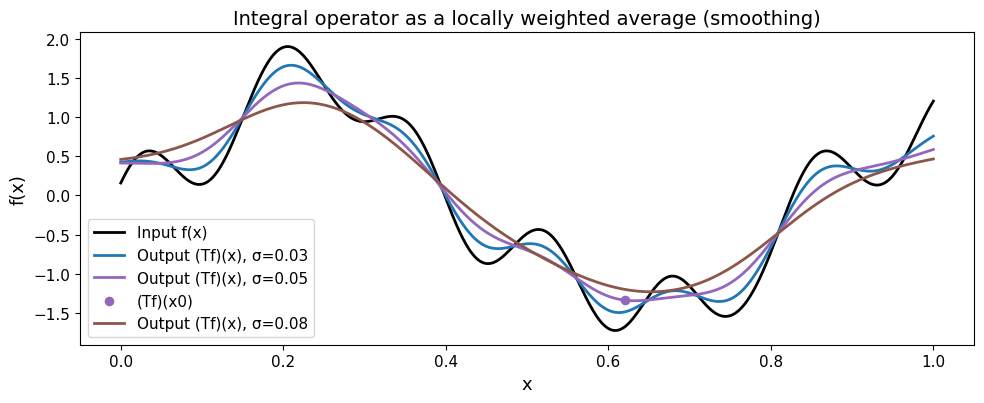

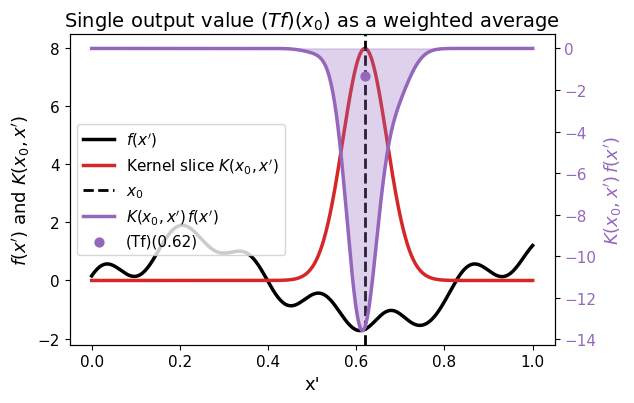

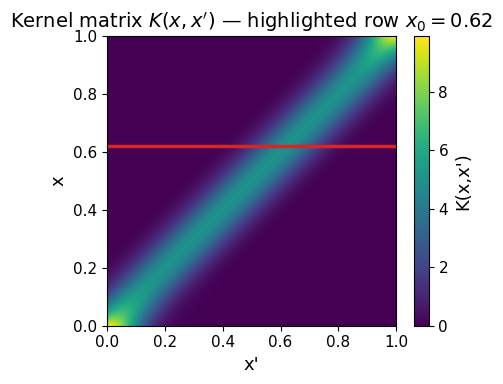

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Integral-operator "blurring" demo
# ----------------------------
# We visualize (Tf)(x) = ∫ K(x,y) f(y) dy where K is a normalized Gaussian window
# so that Tf is a locally weighted average (a blur / smoothing of f).
#
# This script produces 3 figures:
# 1) The input function f and its blurred output Tf
# 2) The kernel slice K(x0, y) for a chosen x0 overlaid on f, plus the pointwise product
# 3) A heatmap of K(x, y) to show it is a "continuous matrix" (rows indexed by x)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

def gaussian_kernel(x_grid: np.ndarray, y_grid: np.ndarray, sigma: float) -> np.ndarray:
    """
    Return K(x,y) evaluated on grids with shape (Nx,) and (Ny,).
    K is normalized in y so that ∫ K(x,y) dy = 1 for each x (discrete approximation).
    """
    X = x_grid[:, None]                 # (Nx, 1)
    Y = y_grid[None, :]                 # (1, Ny)
    K = np.exp(-0.5 * ((X - Y) / sigma) ** 2)

    # Normalize each row so it sums (approximately integrates) to 1
    dy = y_grid[1] - y_grid[0]
    row_sums = (K.sum(axis=1, keepdims=True) * dy)
    K = K / row_sums
    return K

def make_signal(x: np.ndarray) -> np.ndarray:
    """A simple 'busy' function to show smoothing clearly."""
    f = (
        0.8 * np.sin(2 * np.pi * 1.2 * x)
        + 0.35 * np.sin(2 * np.pi * 6.0 * x + 0.7)
        + 0.6 * np.exp(-0.5 * ((x - 0.25) / 0.05) ** 2)   # narrow bump
        - 0.45 * np.exp(-0.5 * ((x - 0.72) / 0.035) ** 2) # narrow dip
    )
    #standard scale f
    f = (f - np.mean(f)) / np.std(f)
    return f

def apply_integral_operator(K: np.ndarray, f: np.ndarray, dy: float) -> np.ndarray:
    """Discrete approximation of Tf(x) = ∫ K(x,y) f(y) dy."""
    return (K @ f) * dy

# Domain and discretization
N = 800
x = np.linspace(0.0, 1.0, N)
y = x.copy()
dy = y[1] - y[0]

# Input function
f = make_signal(x)
x0 = 0.62
ik=1
ix0 = int(np.argmin(np.abs(x - x0)))


# Kernel bandwidths (multiple smoothness levels)
sigmas = [0.03, 0.05, 0.08]
Tf_list = []

for sigma in sigmas:
    K = gaussian_kernel(x, y, sigma)
    Tf = apply_integral_operator(K, f, dy)
    Tf_list.append((sigma, K, Tf))

# ----------------------------
# Figure 1: f and Tf for different sigmas
# ----------------------------
plt.figure(figsize=(10, 4.2))
plt.plot(x, f, linewidth=2.0, label="Input f(x)", color="black")
colors = ["tab:blue", "tab:purple", "tab:brown"]
for i, (sigma, _, Tf) in enumerate(Tf_list):
    plt.plot(x, Tf, linewidth=2.0, label=f"Output (Tf)(x), σ={sigma:g}", color=colors[i])
    if i == ik:
        plt.scatter(x0, Tf[ix0], color=colors[i], s=35, label="(Tf)(x0)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Integral operator as a locally weighted average (smoothing)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: Kernel slice at a single x0
# ----------------------------

# Choose a middle sigma for the slice visualization
sigma, K, Tf = Tf_list[ik]
k_slice = K[ix0, :]  # K(x0, y)

# Normalize k_slice to have comparable vertical scale for plotting overlay on f
# (k_slice integrates to 1; f has its own amplitude; so we scale the slice for overlay only)
scale = 1.0# 0.9 * (np.max(f) - np.min(f))
k_overlay = k_slice #* scale + np.min(f)

product = k_slice * f  # integrand (up to dy)

plt.figure(figsize=(6.5, 4.2))
plt.plot(y, f, linewidth=2.5, label=r"$f(x')$", color='black')
plt.plot(
    y, k_overlay, linewidth=2.5,
    label=fr"Kernel slice $K(x_0,x')$", color="tab:red"
)
plt.axvline(x[ix0], linestyle="--", linewidth=2.0, label=r"$x_0$", color="black")

ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(y, product, linewidth=2.5, label=r"$K(x_0,x')\,f(x')$", color="tab:purple")
ax2.set_ylabel(r"$K(x_0,x')\,f(x')$", color="tab:purple")
ax2.scatter(x0, Tf[ix0], linewidth=3.5, color=colors[ik], s=15, label=f"(Tf)({x0:.2f})")
ax2.fill_between(y, 0, product, color="tab:purple", alpha=0.3)
ax2.tick_params(axis='y', labelcolor="tab:purple")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center left")

ax.set_xlabel(r"x'")
ax.set_ylabel(r"$f(x')$ and $K(x_0,x')$")
ax.set_title(r"Single output value $(Tf)(x_0)$ as a weighted average")

plt.tight_layout()
plt.show()

# ----------------------------
# Figure 3: Heatmap of K(x,y) as a "continuous matrix"
# ----------------------------
# For a clearer heatmap, use a slightly larger sigma to see the band structure
sigma, K, _ = Tf_list[2]

from matplotlib.patches import Rectangle

plt.figure(figsize=(4.6, 4.0))
ax = plt.gca()

im = ax.imshow(
    K,
    aspect="auto",
    origin="lower",
    extent=[y[0], y[-1], x[0], x[-1]],
)

# Height of one row in x-units
dx = x[1] - x[0]

# Red rectangle highlighting the row corresponding to x0
rect = Rectangle(
    (y[0], x[ix0] - dx / 2),
    width=y[-1] - y[0],
    height=dx,
    linewidth=2.5,
    edgecolor="tab:red",
    facecolor="none",
)
ax.add_patch(rect)

ax.set_xlabel(r"x'")
ax.set_ylabel("x")
ax.set_title(fr"Kernel matrix $K(x,x')$ — highlighted row $x_0={x[ix0]:.2f}$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"K(x,x')")

plt.tight_layout()
plt.show()


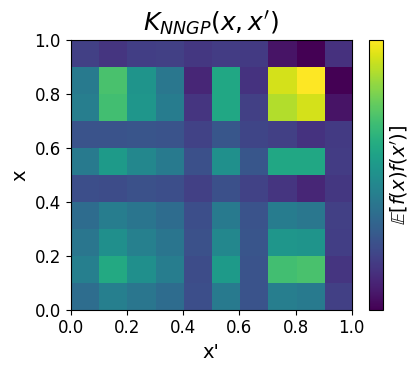

In [30]:
#make me a small symmetric heat map for KNNGP(x,x') where we just take say random uniform
#points in [0,1] and then make a small random gaussian weight neural network with 1 hidden layer
#1D inputs, 1D outputs, say 5 hidden units, and then just get the covariance matrix matrix for each
#pair of inputs and plot that as a heat map
import numpy as np
import matplotlib.pyplot as plt
# Define the neural network parameters
input_dim = 1
hidden_units = 5
output_dim = 1
# Generate random weights and biases
np.random.seed(0)
# Define the neural network function
def neural_network(x):
    h = np.tanh(x @ W1 + b1)  # Hidden layer with tanh activation
    out = h @ W2 + b2         # Output layer
    return out
# Generate random input points in [0, 1]
N = 10
X = np.random.uniform(0, 1, (N, input_dim))
# Evaluate H number of neural net random initializations to approximate the NNGP
H = 1000
Y = np.zeros((N, H))
for h in range(H):
    # Generate new random weights and biases for each initialization
    W1 = np.random.normal(0, 1/np.sqrt(input_dim), (input_dim, hidden_units))
    b1 = np.random.normal(0, 1/np.sqrt(input_dim), (hidden_units,))
    W2 = np.random.normal(0, 1/np.sqrt(hidden_units), (hidden_units, output_dim))
    b2 = np.random.normal(0, 1/np.sqrt(hidden_units), (output_dim,))
    Y[:, h] = neural_network(X).flatten()

# Compute the covariance matrix KNNGP(x,x')
K = np.cov(Y)
# Plot the heatmap of the covariance matrix
plt.figure(figsize=(4.6, 4.0))
ax = plt.gca()

im = ax.imshow(
    K,
    aspect="auto",
    origin="lower",
    extent=[0, 1, 0, 1],
)

ax.set_xlabel(r"x'")
ax.set_ylabel("x")
ax.set_title(r"$K_{NNGP}(x,x')$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\mathbb{E}\left[f(x)f(x')\right]$")
#turn off cbar tick labels
cbar.set_ticks([])

plt.tight_layout()
plt.show()

In [12]:
K.shape

(1000, 1000)

In [13]:
K

array([[ 0.0369565 , -0.02896536, -0.05086984, ...,  0.00874269,
         0.03918134,  0.06944102],
       [-0.02896536,  0.02270319,  0.03990611, ..., -0.00684128,
        -0.03067919, -0.05439101],
       [-0.05086984,  0.03990611,  0.07218784, ..., -0.01142051,
        -0.05229589, -0.09376064],
       ...,
       [ 0.00874269, -0.00684128, -0.01142051, ...,  0.00224351,
         0.0097376 ,  0.01695175],
       [ 0.03918134, -0.03067919, -0.05229589, ...,  0.0097376 ,
         0.04279399,  0.07502692],
       [ 0.06944102, -0.05439101, -0.09376064, ...,  0.01695175,
         0.07502692,  0.13206038]])